In [65]:
import yfinance as yf

data = yf.download("AAPL", start="2000-01-01", end="2025-11-10")
print(data.head(-1))


/tmp/ipython-input-2021146064.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2000-01-01", end="2025-11-10")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2000-01-03    0.839281    0.843498    0.762429    0.786328  535796800
2000-01-04    0.768521    0.829440    0.758680    0.811633  512377600
2000-01-05    0.779767    0.828971    0.772269    0.777892  778321600
2000-01-06    0.712287    0.802260    0.712287    0.795700  767972800
2000-01-07    0.746027    0.757274    0.716037    0.723534  460734400
...                ...         ...         ...         ...        ...
2025-10-31  270.108154  277.051436  268.899335  276.721738   86167100
2025-11-03  268.789429  270.587704  265.992153  270.158128   50194600
2025-11-04  269.778473  271.227050  267.360803  268.070107   49274800
2025-11-05  269.878387  271.436874  266.671474  268.349840   43683100
2025-11-06  269.508728  273.135217  267.630574  267.630574   51204000

[6502 rows x 5 colu

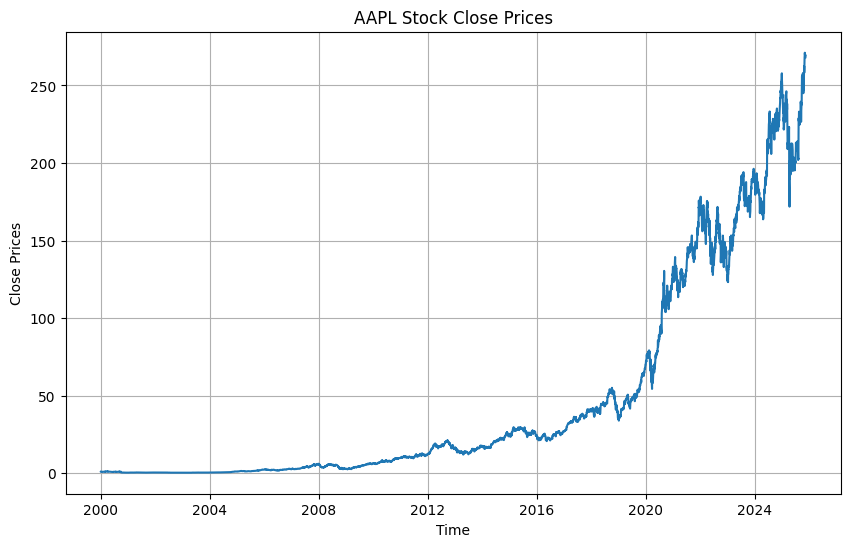

In [66]:
# Plot the line chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(data['Close'])
plt.xlabel('Time')
plt.ylabel('Close Prices')
plt.title('AAPL Stock Close Prices')
plt.grid(True)
plt.show()

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

data["Close_Open_Ratio"] = data["Close"] / data["Open"]
data["High_Low_Ratio"] = data["High"] / data["Low"]
data["High_Close_Ratio"] = data["High"] / data["Close"]
data["Low_Open_Ratio"] = data["Low"] / data["Open"]


data = data.dropna()
print(data[["Open", "Close","Close_Open_Ratio", "High_Low_Ratio","High_Close_Ratio","Low_Open_Ratio"]].head())

X = data[['Open', 'High', 'Low',"High_Low_Ratio","High_Close_Ratio","Low_Open_Ratio", 'Volume']]
y = data["Close"].shift(-1)   # prédire le prix du lendemain

# Supprimer la dernière ligne (où y est NaN à cause du shift)
X = X.iloc[:-1]
y = y.dropna()
scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)
X_scaled = scaler.fit_transform(X_train)  # Normalise chaque colonne individuellement

Price           Open     Close Close_Open_Ratio High_Low_Ratio  \
Ticker          AAPL      AAPL                                   
Date                                                             
2000-01-03  0.786328  0.839281         1.067342       1.106331   
2000-01-04  0.811633  0.768521         0.946883       1.093267   
2000-01-05  0.777892  0.779767         1.002410       1.073422   
2000-01-06  0.795700  0.712287         0.895170       1.126316   
2000-01-07  0.723534  0.746027         1.031088       1.057591   

Price      High_Close_Ratio Low_Open_Ratio  
Ticker                                      
Date                                        
2000-01-03         1.005025       0.969606  
2000-01-04         1.079268       0.934758  
2000-01-05         1.063101       0.992772  
2000-01-06         1.126316       0.895170  
2000-01-07         1.015076       0.989638  


In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()

# Scale X_test using the scaler fitted on X_train
X_test_scaled = scaler.transform(X_test)

lr.fit(X_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

print("Score:",lr.score(X_scaled,y_train))
print("MAE:", mean_absolute_error(y_test, pred_lr))
print("R²:", r2_score(y_test, pred_lr))

Score: 0.9995855542425723
MAE: 1.8377081918791176
R²: 0.9981888577939843


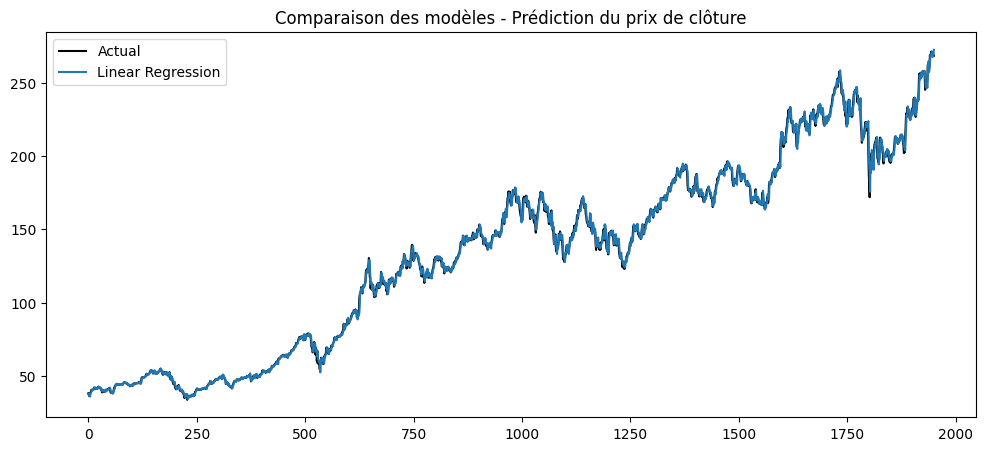

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual", color='black')
plt.plot(pred_lr, label="Linear Regression")
plt.legend()
plt.title("Comparaison des modèles - Prédiction du prix de clôture")
plt.show()


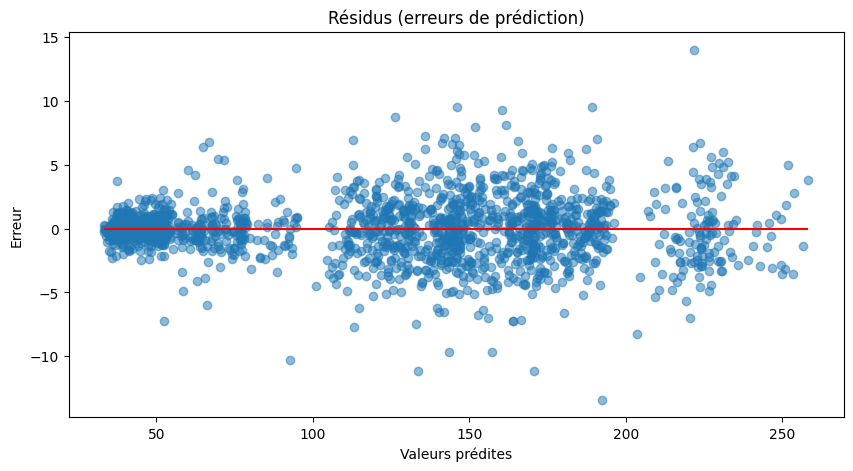

In [32]:

plt.figure(figsize=(10,5))
plt.scatter(y_test_pred, y_test_pred - y_test, alpha=0.5)
plt.hlines(y=0, xmin=y_test_pred.min(), xmax=y_test_pred.max(), colors='r')
plt.title("Résidus (erreurs de prédiction)")
plt.xlabel("Valeurs prédites")
plt.ylabel("Erreur")
plt.show()

Text(0, 0.5, 'Predicted')

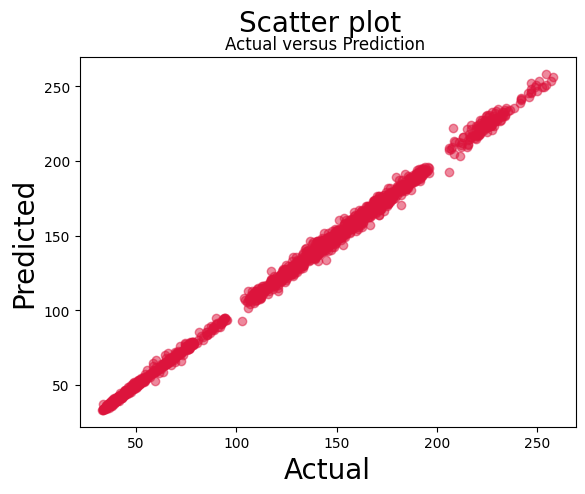

In [9]:
#using scatter plot compare the actual and predicted data
fig = plt.figure()
plt.scatter(y_test, pred_lr, c='crimson',alpha=0.5)
fig.suptitle('Scatter plot', fontsize=20)
plt.title('Actual versus Prediction ')
plt.xlabel('Actual', fontsize=20)
plt.ylabel('Predicted', fontsize=20)

In [46]:
import pandas as pd
#load actual and predecited values side by side
dframe=pd.DataFrame({'actual':y_test.values.flatten(),'Predicted':pred_lr.flatten()})
#flatten toget single axis of data (1 dimension only)
display(dframe.head(15))

,actual,Predicted
0,33.355175,33.563856
1,33.492302,33.448994
2,33.176186,33.457017
3,33.513226,33.238475
4,33.717777,33.579221
5,33.827019,33.731997
6,33.875839,33.810951
7,34.347691,33.802627
8,34.642876,34.392109
9,34.763756,34.563856


In [75]:
X_last = X.iloc[[-1]]  # dernière ligne sous forme de DataFrame


close_today = data['Close'].iloc[-1]

X_last = scaler.transform(X_last)
predicted_close = lr.predict(X_last)



print(f"Prix de clôture du {data.index[-1]} : {close_today.iloc[0]:.2f} USD")
print(f"Prix de clôture prédit pour demain : {predicted_close[0].item():.2f} USD")
diff = predicted_close[0].item() - close_today.iloc[0]
print(f"Différence attendue : {diff:.2f} USD")

Prix de clôture du 2025-11-07 00:00:00 : 268.21 USD
Prix de clôture prédit pour demain : 272.31 USD
Différence attendue : 4.10 USD
